<a href="https://colab.research.google.com/github/write2chrischacko/Healthcare-Appointment-No-Show-Analysis-and-Prediction/blob/main/Healthcare_Appointment_No_Show_Analysis_%26_Prediction_CC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import matplotlib.cm as cm
import seaborn as sns
import warnings

In [ ]:
# Load dataset
df = pd.read_csv('/content/MedicalAppointment.csv')
display(df.head(10))

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0.0,1.0,0.0,0.0,0.0,0.0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0.0,0.0,0.0,0.0,0.0,0.0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0.0,0.0,0.0,0.0,0.0,0.0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0.0,0.0,0.0,0.0,0.0,0.0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0.0,1.0,1.0,0.0,0.0,0.0,No
5,9.598513e+13,5626772,F,2016-04-27T08:36:51Z,2016-04-29T00:00:00Z,76,REPÚBLICA,0.0,1.0,0.0,0.0,0.0,0.0,No
6,7.336882e+14,5630279,F,2016-04-27T15:05:12Z,2016-04-29T00:00:00Z,23,GOIABEIRAS,0.0,0.0,0.0,0.0,0.0,0.0,Yes
7,3.449833e+12,5630575,F,2016-04-27T15:39:58Z,2016-04-29T00:00:00Z,39,GOIABEIRAS,0.0,0.0,0.0,0.0,0.0,0.0,Yes
8,5.639473e+13,5638447,F,2016-04-29T08:02:16Z,2016-04-29T00:00:00Z,21,ANDORINHAS,0.0,0.0,0.0,0.0,0.0,0.0,No
9,7.812456e+13,5629123,F,2016-04-27T12:48:25Z,2016-04-29T00:00:00Z,19,CONQUISTA,0.0,0.0,0.0,0.0,0.0,0.0,No


In [ ]:
# Standardising column names
df.columns = (
    df.columns
      .str.upper()
      .str.replace(r'\s+', '_', regex=True)
      .str.replace('-', '_')
)

df = df.rename(columns={
    'PATIENTID':      'PATIENT_ID',
    'APPOINTMENTID':  'APPOINTMENT_ID',
    'SCHEDULEDDAY':   'SCHEDULED_DAY',
    'APPOINTMENTDAY': 'APPOINTMENT_DAY',
    'HIPERTENSION':   'HYPERTENSION',
    'HANDCAP':        'HANDICAP',
})

print("Columns:", df.columns.tolist(), "\n")

Columns: ['PATIENT_ID', 'APPOINTMENT_ID', 'GENDER', 'SCHEDULED_DAY', 'APPOINTMENT_DAY', 'AGE', 'NEIGHBOURHOOD', 'SCHOLARSHIP', 'HYPERTENSION', 'DIABETES', 'ALCOHOLISM', 'HANDICAP', 'SMS_RECEIVED', 'NO_SHOW'] 



In [ ]:
# Checking Nulls
null_values = df.isnull().sum()
print("Null counts per column:")
print(null_values)
print(f"\nTotal nulls: {null_values.sum()}\n")

Null counts per column:
PATIENT_ID         0
APPOINTMENT_ID     0
GENDER             0
SCHEDULED_DAY      0
APPOINTMENT_DAY    0
AGE                0
NEIGHBOURHOOD      0
SCHOLARSHIP        1
HYPERTENSION       1
DIABETES           1
ALCOHOLISM         1
HANDICAP           1
SMS_RECEIVED       1
NO_SHOW            1
dtype: int64

Total nulls: 7



In [ ]:
# Fix data types
df['PATIENT_ID']     = df['PATIENT_ID'].astype(str)
df['APPOINTMENT_ID'] = df['APPOINTMENT_ID'].astype(str)

df['SCHEDULED_DAY']   = pd.to_datetime(df['SCHEDULED_DAY'],   utc=True).dt.tz_localize(None)
df['APPOINTMENT_DAY'] = pd.to_datetime(df['APPOINTMENT_DAY'], utc=True).dt.tz_localize(None)

df['NO_SHOW'] = (df['NO_SHOW'] == 'Yes').astype(int)

df['NEIGHBOURHOOD'] = df['NEIGHBOURHOOD'].str.strip().str.title()

print("Updated dtypes:")
print(df.dtypes, "\n")

Updated dtypes:
PATIENT_ID                 object
APPOINTMENT_ID             object
GENDER                     object
SCHEDULED_DAY      datetime64[ns]
APPOINTMENT_DAY    datetime64[ns]
AGE                         int64
NEIGHBOURHOOD              object
SCHOLARSHIP               float64
HYPERTENSION              float64
DIABETES                  float64
ALCOHOLISM                float64
HANDICAP                  float64
SMS_RECEIVED              float64
NO_SHOW                     int64
dtype: object 



In [ ]:
# Convert Handicap Values to True/False
df['HANDICAP'] = df['HANDICAP'].apply(lambda x: 1 if x > 0 else 0)

In [ ]:
df['HANDICAP'].value_counts()

,count
HANDICAP,
0,95145
1,1969


In [ ]:
df.describe()

,SCHEDULED_DAY,APPOINTMENT_DAY,AGE,SCHOLARSHIP,HYPERTENSION,DIABETES,ALCOHOLISM,HANDICAP,SMS_RECEIVED,NO_SHOW
count,97114,97114,97114.000000,97113.000000,97113.000000,97113.000000,97113.000000,97114.000000,97113.000000,97114.000000
mean,2016-05-07 01:19:42.282390016,2016-05-16 18:16:00.405297152,37.112455,0.098617,0.197708,0.072308,0.029224,0.020275,0.303924,0.202721
min,2015-11-10 07:13:56,2016-04-29 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2016-04-28 15:18:14.500000,2016-05-09 00:00:00,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2016-05-09 09:21:13.500000,2016-05-16 00:00:00,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2016-05-18 09:37:53.249999872,2016-05-25 00:00:00,56.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,2016-06-08 20:07:23,2016-06-08 00:00:00,115.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
std,NaN,NaN,23.158119,0.298149,0.398273,0.258998,0.168434,0.140941,0.459953,0.402028


In [ ]:
df.describe(include='object')

,PATIENT_ID,APPOINTMENT_ID,GENDER,NEIGHBOURHOOD
count,97114,97114,97114,97114
unique,57755,97114,2,82
top,822145925426128.0,5444861,F,Jardim Camburi
freq,65,1,63176,7429


In [ ]:
print(f"\nAge < 0  : {(df['AGE'] < 0).sum()}")
print(f"Age > 100: {(df['AGE'] > 100).sum()}")

df = df[df['AGE'] >= 0].reset_index(drop=True)      # drop the negative age record
df['AGE'] = df['AGE'].clip(upper=100)                # cap implausible values


Age < 0  : 0
Age > 100: 6


In [ ]:
df['WAIT_DAYS'] = (df['APPOINTMENT_DAY'] - df['SCHEDULED_DAY']).dt.days

neg_wait = df['WAIT_DAYS'] < 0
print(f"\nRows where appointment precedes scheduling (true errors): {neg_wait.sum()}")
if neg_wait.sum():
    df = df[~neg_wait].reset_index(drop=True)
    print("Dropped.")


Rows where appointment precedes scheduling (true errors): 34459
Dropped.


In [ ]:
dupes = df.duplicated(subset='APPOINTMENT_ID').sum()
print(f"\nDuplicate APPOINTMENT_IDs: {dupes}")
if dupes:
    df = df.drop_duplicates(subset='APPOINTMENT_ID').reset_index(drop=True)


Duplicate APPOINTMENT_IDs: 0


In [ ]:
# Day of week the appointment falls on (0=Mon … 6=Sun)
df['APPT_DOW']     = df['APPOINTMENT_DAY'].dt.dayofweek
df['APPT_DOW_NAME']= df['APPOINTMENT_DAY'].dt.day_name()
df['APPT_DOW_NAME'] = df['APPOINTMENT_DAY'].dt.day_name()

# Comorbidity count per patient-visit
df['COMORBIDITY_COUNT'] = (
    df[['HYPERTENSION', 'DIABETES', 'ALCOHOLISM']].sum(axis=1).astype('uint8')
)

# Age buckets
df['AGE_GROUP'] = pd.cut(
    df['AGE'],
    bins=[-1, 12, 17, 35, 60, 100],
    labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
)

print("\nEngineered columns added: WAIT_DAYS, APPT_DOW, APPT_DOW_NAME, COMORBIDITY_COUNT, AGE_GROUP")


Engineered columns added: WAIT_DAYS, APPT_DOW, APPT_DOW_NAME, COMORBIDITY_COUNT, AGE_GROUP


In [ ]:
print(df[["APPOINTMENT_DAY", "APPT_DOW", "APPT_DOW_NAME"]].tail(50))

      APPOINTMENT_DAY  APPT_DOW APPT_DOW_NAME
62605      2016-06-07         1       Tuesday
62606      2016-06-07         1       Tuesday
62607      2016-06-08         2     Wednesday
62608      2016-06-08         2     Wednesday
62609      2016-06-08         2     Wednesday
62610      2016-06-08         2     Wednesday
62611      2016-06-08         2     Wednesday
62612      2016-06-08         2     Wednesday
62613      2016-06-08         2     Wednesday
62614      2016-06-08         2     Wednesday
62615      2016-06-08         2     Wednesday
62616      2016-06-08         2     Wednesday
62617      2016-06-08         2     Wednesday
62618      2016-06-08         2     Wednesday
62619      2016-06-08         2     Wednesday
62620      2016-06-08         2     Wednesday
62621      2016-06-08         2     Wednesday
62622      2016-06-07         1       Tuesday
62623      2016-06-06         0        Monday
62624      2016-06-03         4        Friday
62625      2016-06-03         4   

# **Exploratory Data Analysis**
## **Descriptive Analysis**

In [ ]:
sns.set_theme(style='whitegrid', palette='Paired')
plt.rcParams.update({
    'figure.dpi'       : 120,
    'figure.facecolor' : '#F8F9FA',
    'axes.facecolor'   : '#FFFFFF',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 11,
    'xtick.labelsize'  : 10,
    'ytick.labelsize'  : 10,
    'font.family'      : 'DejaVu Sans',
})

In [ ]:
total = len(df)

print(f"\nTotal Patients : {total:,}")

print(f"\nFinancial")
print(f"Scholarship: {df['SCHOLARSHIP'].sum():,} ({df['SCHOLARSHIP'].mean()*100:.1f}%)")

print(f"\nDisability")
print(f"Handicap: {df['HANDICAP'].sum():,} ({df['HANDICAP'].mean()*100:.1f}%)")

print(f"\nMedical Conditions")
print(f"Hypertension: {df['HYPERTENSION'].sum():,} ({df['HYPERTENSION'].mean()*100:.1f}%)")
print(f"Diabetes: {df['DIABETES'].sum():,} ({df['DIABETES'].mean()*100:.1f}%)")
print(f"Alcoholism: {df['ALCOHOLISM'].sum():,} ({df['ALCOHOLISM'].mean()*100:.1f}%)")

print(f"\nCommunication")
print(f"SMS Received: {df['SMS_RECEIVED'].sum():,} ({df['SMS_RECEIVED'].mean()*100:.1f}%)")


Total Patients : 62,655

Financial
Scholarship: 5,799.0 (9.3%)

Disability
Handicap: 1,138 (1.8%)

Medical Conditions
Hypertension: 13,149.0 (21.0%)
Diabetes: 4,719.0 (7.5%)
Alcoholism: 1,556.0 (2.5%)

Communication
SMS Received: 29,515.0 (47.1%)


In [ ]:
total       = len(df)
no_show_n   = df['NO_SHOW'].sum()
show_n      = total - no_show_n
no_show_pct = no_show_n / total * 100

print(f"  Total appointments: {total:>10,}")
print(f"  Showed up (0): {show_n:>10,}  ({100 - no_show_pct:.1f}%)")
print(f"  No-show    (1): {no_show_n:>10,}  ({no_show_pct:.1f}%)")

  Total appointments:     62,655
  Showed up (0):     44,630  (71.2%)
  No-show    (1):     18,025  (28.8%)


/tmp/ipykernel_6199/720672059.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='GENDER', palette=['lightpink', 'skyblue'])


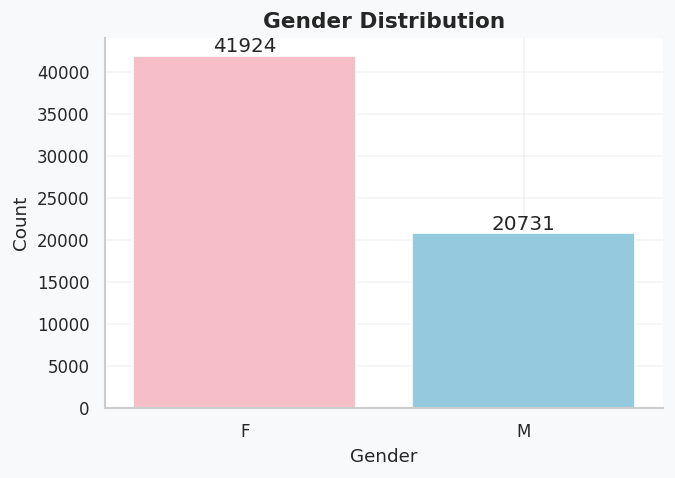

In [ ]:
# Gender Distribution
plt.figure(figsize=(6,4))
ax = sns.countplot(data=df, x='GENDER', palette=['lightpink', 'skyblue'])

# Add value counts on bars
for container in ax.containers:
    ax.bar_label(container)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.grid(True, alpha=0.2)
plt.show()

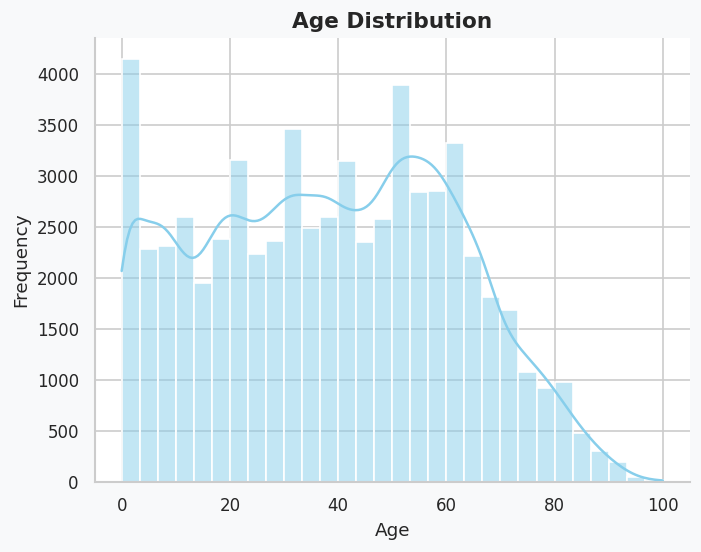

In [ ]:
# Age distribution
sns.histplot(df['AGE'], bins=30, kde=True, color='skyblue')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

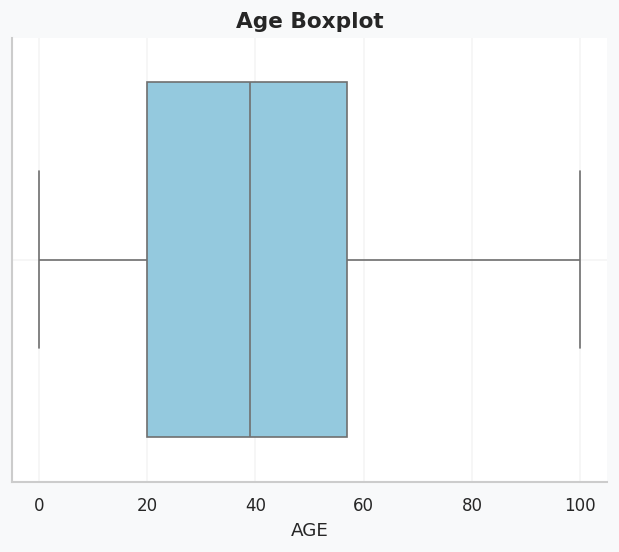

In [ ]:
sns.boxplot(x=df['AGE'], color='skyblue')

plt.title("Age Boxplot")
plt.grid(True, alpha=0.2)
plt.show()

In [ ]:
# Top 10 neighbourhoods
top_locations = df['NEIGHBOURHOOD'].value_counts().head(10)

print(top_locations)

NEIGHBOURHOOD
Jardim Camburi     4974
Maria Ortiz        3201
Jardim Da Penha    2454
Itararé            2244
Resistência        2214
Centro             2004
Tabuazeiro         1600
Bonfim             1570
Caratoíra          1547
São Pedro          1458
Name: count, dtype: int64


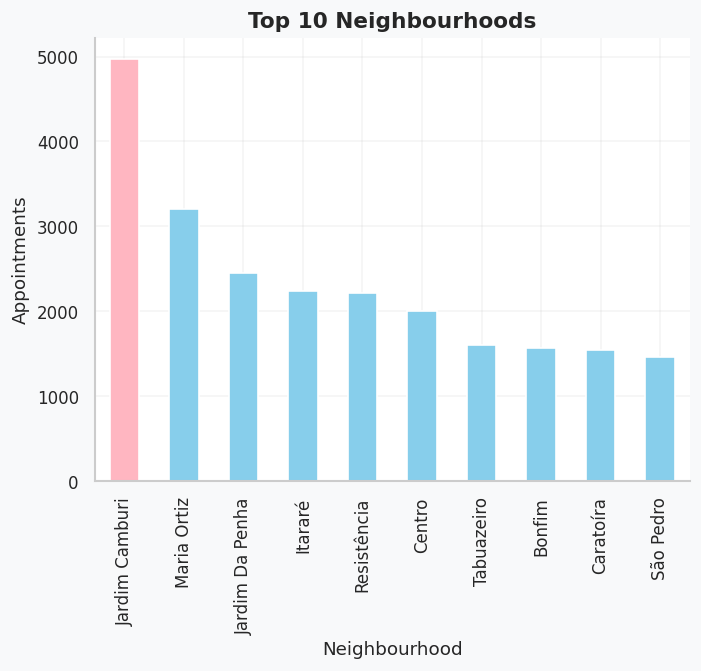

In [ ]:
colors = ['skyblue'] * len(top_locations)
colors[0] = 'lightpink'

top_locations.plot(kind='bar', color=colors)

plt.title("Top 10 Neighbourhoods")
plt.xlabel("Neighbourhood")
plt.ylabel("Appointments")
plt.xticks(rotation=90)
plt.grid(True, alpha=0.2)
plt.show()

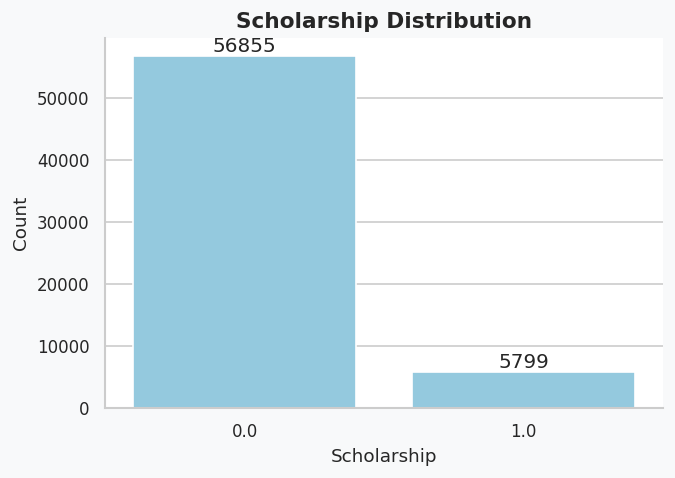

In [ ]:
# Scholarship distribution
plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x='SCHOLARSHIP', color='skyblue')
for container in ax.containers:
    ax.bar_label(container)

plt.title("Scholarship Distribution")
plt.xlabel("Scholarship")
plt.ylabel("Count")
plt.show()

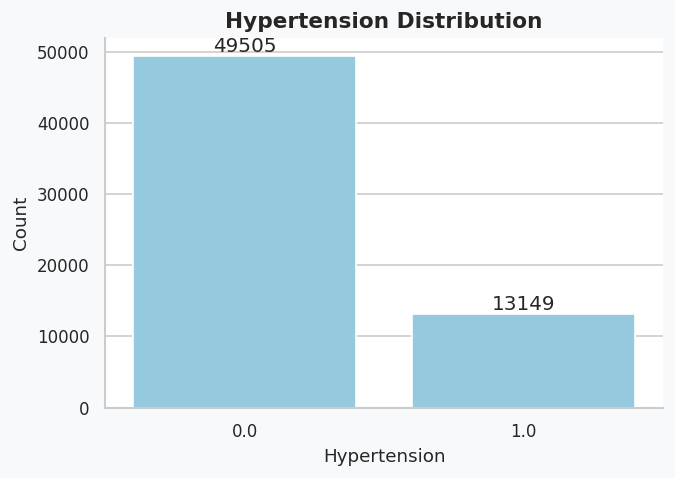

In [ ]:
# Hypertension Distribution
plt.figure(figsize=(6,4))

ax= sns.countplot(data=df, x='HYPERTENSION', color='skyblue')
for container in ax.containers:
    ax.bar_label(container)

plt.title("Hypertension Distribution")
plt.xlabel("Hypertension")
plt.ylabel("Count")
plt.show()

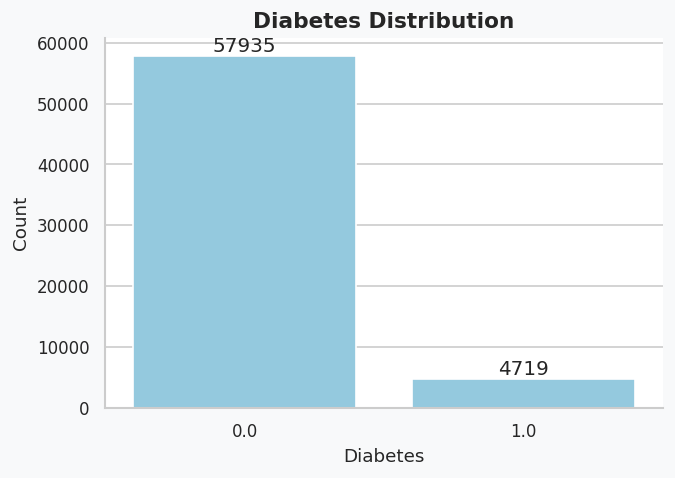

In [ ]:
# Diabetes Distribution
plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x='DIABETES', color='skyblue')
for container in ax.containers:
    ax.bar_label(container)

plt.title("Diabetes Distribution")
plt.xlabel("Diabetes")
plt.ylabel("Count")
plt.show()

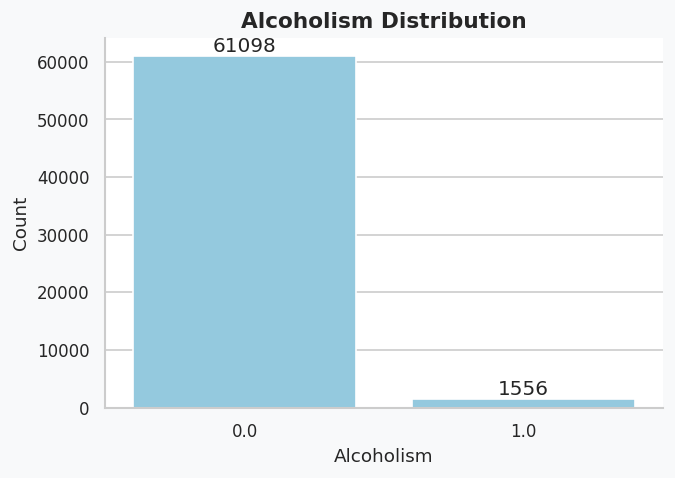

In [ ]:
# Alcoholism Distribution
plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x='ALCOHOLISM', color='skyblue')
for container in ax.containers:
    ax.bar_label(container)

plt.title("Alcoholism Distribution")
plt.xlabel("Alcoholism")
plt.ylabel("Count")
plt.show()

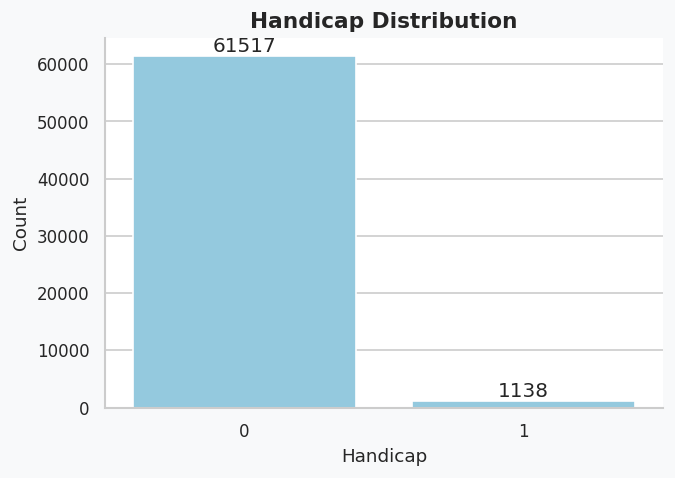

In [ ]:
# Handicap Distribution
plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x='HANDICAP', color='skyblue')

for container in ax.containers:
    ax.bar_label(container)

plt.title("Handicap Distribution")
plt.xlabel("Handicap")
plt.ylabel("Count")

plt.show()

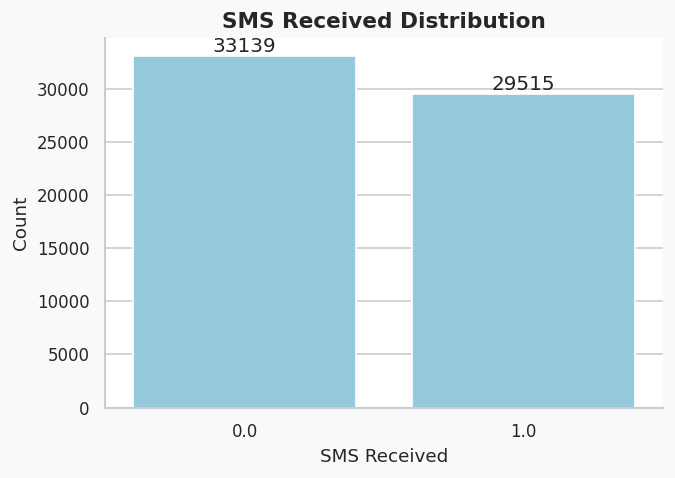

In [ ]:
# SMS Received Distribution
plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x='SMS_RECEIVED', color='skyblue')
for container in ax.containers:
    ax.bar_label(container)

plt.title("SMS Received Distribution")
plt.xlabel("SMS Received")
plt.ylabel("Count")
plt.show()

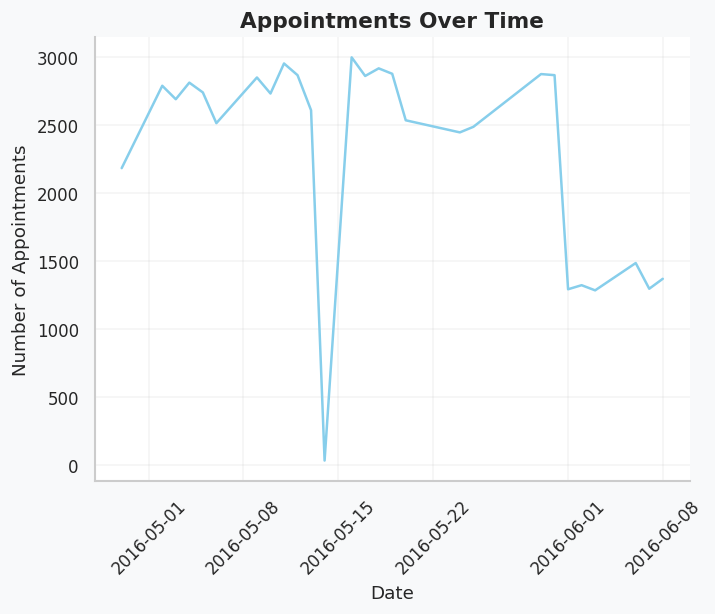

In [ ]:
# Appointment trend
appointments_per_day = df.groupby(
    df['APPOINTMENT_DAY'].dt.date
).size()

appointments_per_day.plot(color='skyblue')

plt.title("Appointments Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Appointments")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.2)
plt.show()

In [ ]:
# Create Waiting Days column
df['WAITING_DAYS'] = (
    df['APPOINTMENT_DAY'] - df['SCHEDULED_DAY']
).dt.days

df = df[df['WAITING_DAYS'] >= 0]    # Remove negative wait days

df['WAITING_DAYS'].describe()

,WAITING_DAYS
count,62655.000000
mean,14.773314
std,16.415600
min,0.000000
25%,3.000000
50%,9.000000
75%,21.000000
max,175.000000


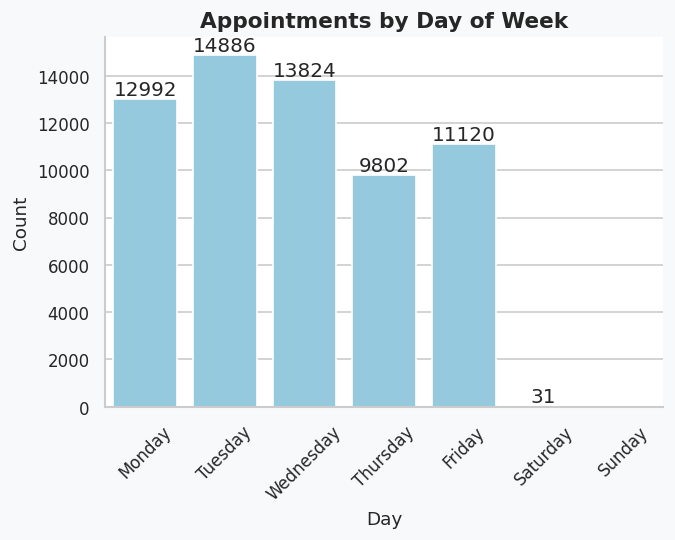

In [ ]:
# Waiting time analysis
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=df,
    x='APPT_DOW_NAME',
    order=['Monday','Tuesday','Wednesday',
           'Thursday','Friday','Saturday','Sunday'], color='skyblue'
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Appointments by Day of Week")
plt.xlabel("Day")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.show()

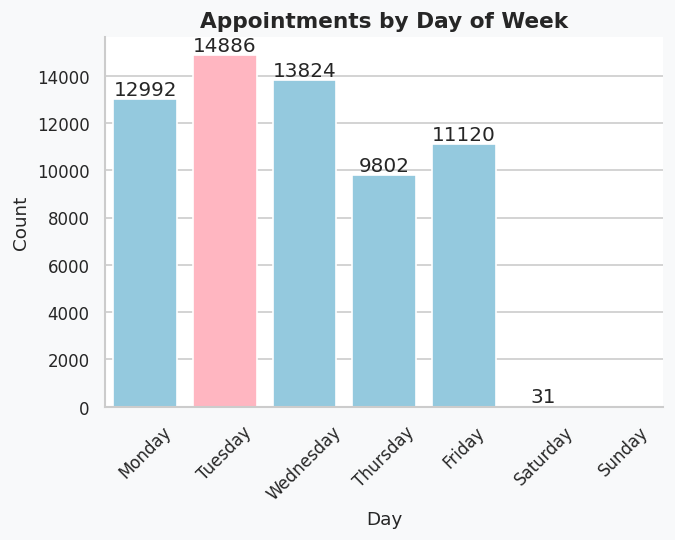

In [ ]:
plt.figure(figsize=(6,4))
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

ax = sns.countplot(
    data=df,
    x='APPT_DOW_NAME',
    order=day_order,
    color='skyblue'
)

heights = [p.get_height() for p in ax.patches]
max_height = max(heights)
for p in ax.patches:
    if p.get_height() == max_height:
        p.set_facecolor('lightpink')

for container in ax.containers:
    ax.bar_label(container)

plt.title("Appointments by Day of Week")
plt.xlabel("Day")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

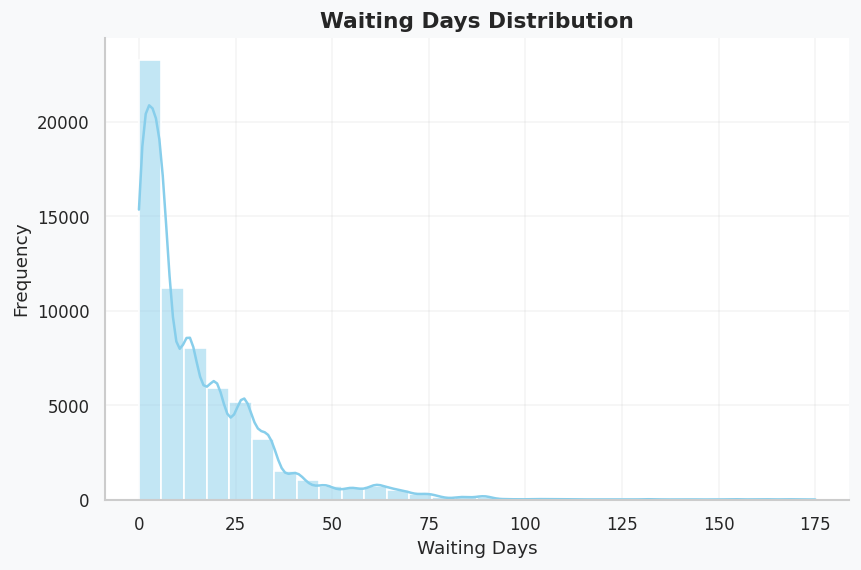

In [ ]:
plt.figure(figsize=(8,5))

ax = sns.histplot(data=df, x='WAITING_DAYS', bins=30, kde=True, color='skyblue')

plt.title("Waiting Days Distribution")
plt.xlabel("Waiting Days")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.2)
plt.show()

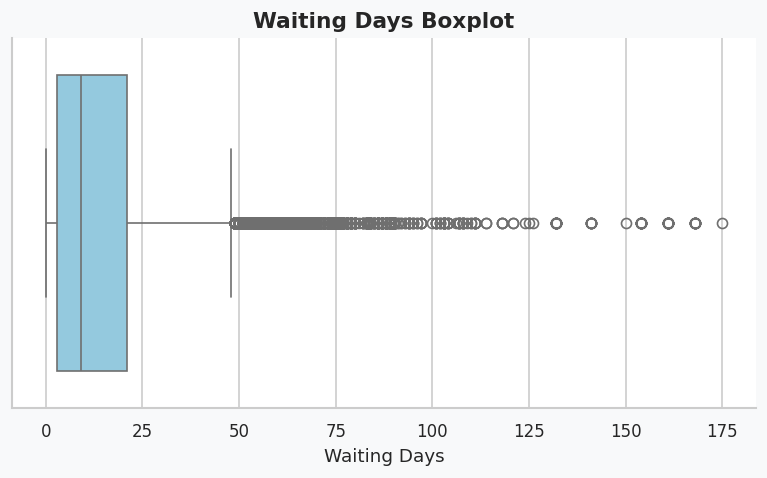

In [ ]:
plt.figure(figsize=(8,4))

sns.boxplot(data=df, x='WAITING_DAYS', color='skyblue')

plt.title("Waiting Days Boxplot")
plt.xlabel("Waiting Days")

plt.show()

In [ ]:
print("Average Waiting Days:", round(df['WAITING_DAYS'].mean(), 2))
print("Maximum Waiting Days:", df['WAITING_DAYS'].max())
print("Minimum Waiting Days:", df['WAITING_DAYS'].min())

Average Waiting Days: 14.77
Maximum Waiting Days: 175
Minimum Waiting Days: 0


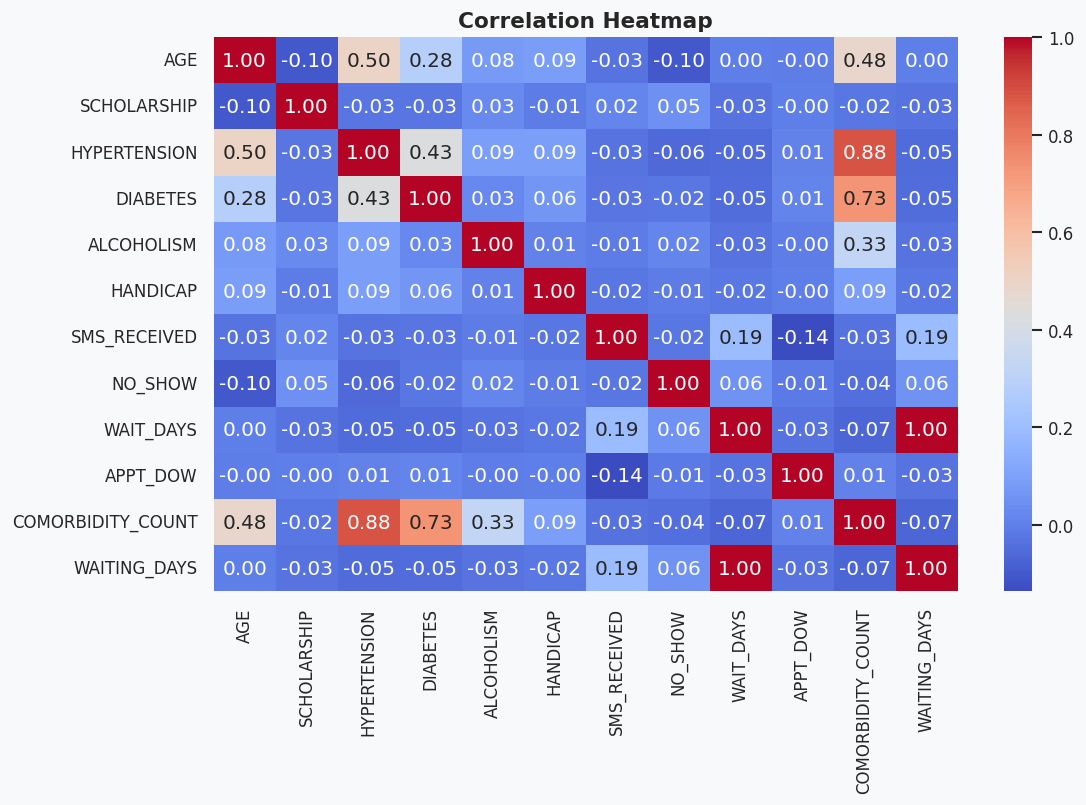

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

## **Target Variable Analysis**

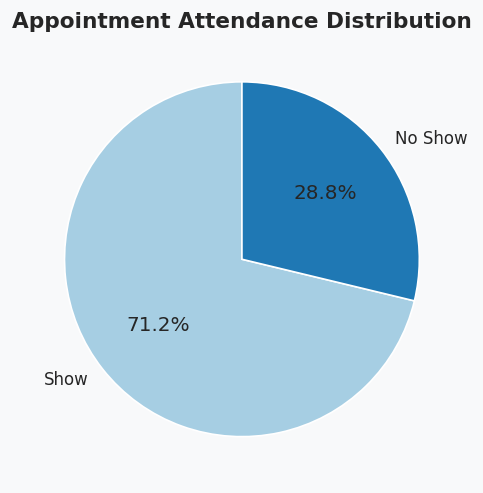

In [ ]:
labels = ['Show', 'No Show']
sizes = df['NO_SHOW'].value_counts().sort_index()

plt.pie(sizes,
        labels=labels,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Appointment Attendance Distribution")
plt.show()

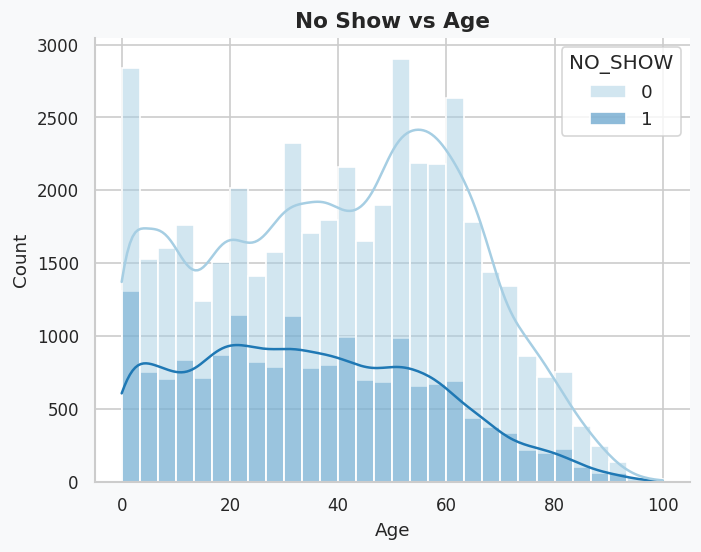

In [ ]:
# No show vs Age
sns.histplot(data=df, x='AGE', hue='NO_SHOW', bins=30, kde=True)

plt.title("No Show vs Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

In [ ]:
df.groupby('NO_SHOW')['AGE'].mean()

,AGE
NO_SHOW,
0,40.070737
1,34.854036


In [ ]:
# No shwo vs Gender
gender_no_show = pd.crosstab(df['GENDER'], df['NO_SHOW'])
print(gender_no_show)

NO_SHOW      0      1
GENDER               
F        29853  12071
M        14777   5954


<Figure size 720x480 with 0 Axes>

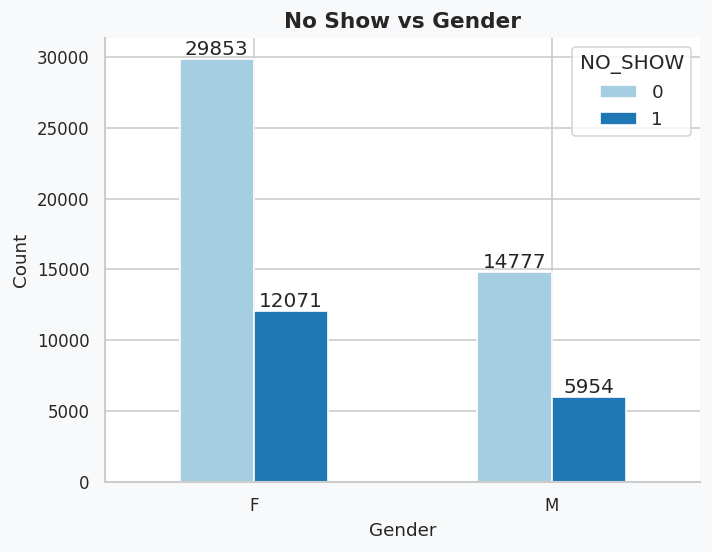

In [ ]:
plt.figure(figsize=(6,4))
ax=gender_no_show.plot(kind='bar')
for container in ax.containers:
    ax.bar_label(container)

plt.title("No Show vs Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

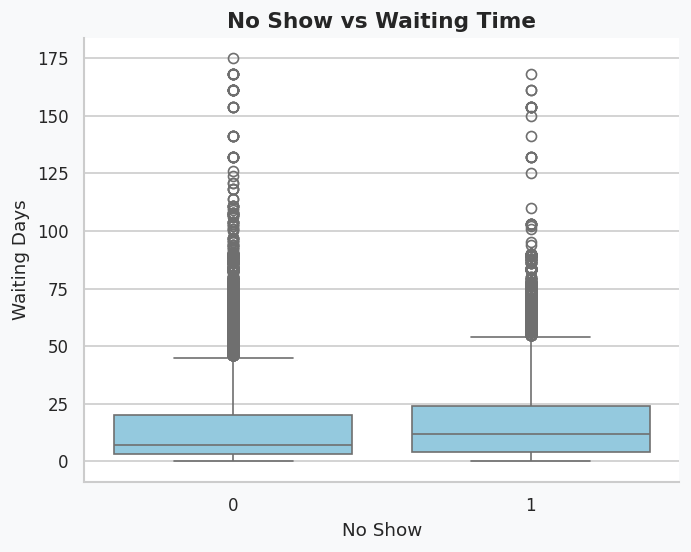

In [ ]:
sns.boxplot(x='NO_SHOW', y='WAITING_DAYS', data=df, color='skyblue')

plt.title("No Show vs Waiting Time")
plt.xlabel("No Show")
plt.ylabel("Waiting Days")
plt.show()

In [ ]:
# Average Waiting Time
df.groupby('NO_SHOW')['WAITING_DAYS'].mean()

,WAITING_DAYS
NO_SHOW,
0,14.179364
1,16.243939


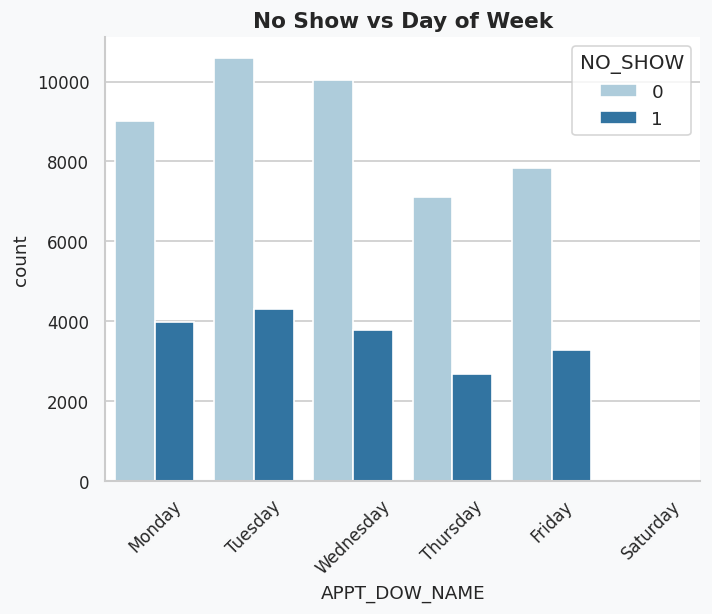

In [ ]:
# No Show vs Day of Week
sns.countplot(data=df,
              x='APPT_DOW_NAME',
              hue='NO_SHOW',
              order=['Monday','Tuesday','Wednesday',
                     'Thursday','Friday','Saturday'])

plt.title("No Show vs Day of Week")
plt.xticks(rotation=45)
plt.show()

NO_SHOW           0     1
SMS_RECEIVED             
0.0           23299  9840
1.0           21330  8185


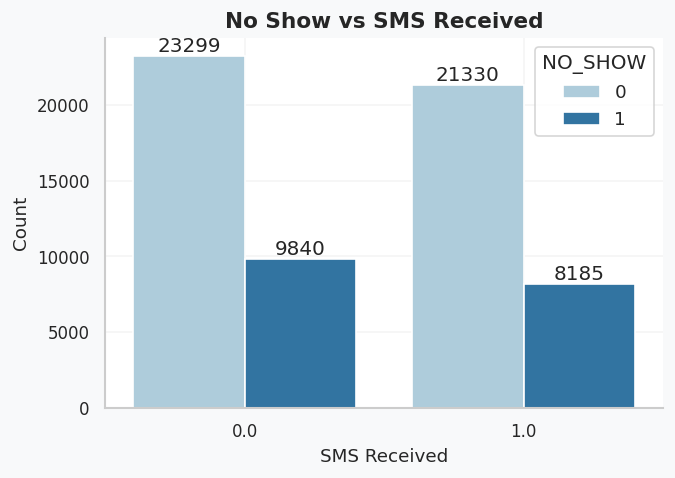

In [ ]:
# No Show vs SMS Received
sms_analysis = pd.crosstab(df['SMS_RECEIVED'], df['NO_SHOW'])
print(sms_analysis)

plt.figure(figsize=(6,4))
ax=sns.countplot(data=df, x='SMS_RECEIVED', hue='NO_SHOW')
for container in ax.containers:
    ax.bar_label(container)

plt.title("No Show vs SMS Received")
plt.xlabel("SMS Received")
plt.ylabel("Count")
plt.grid(True, alpha=0.2)
plt.show()

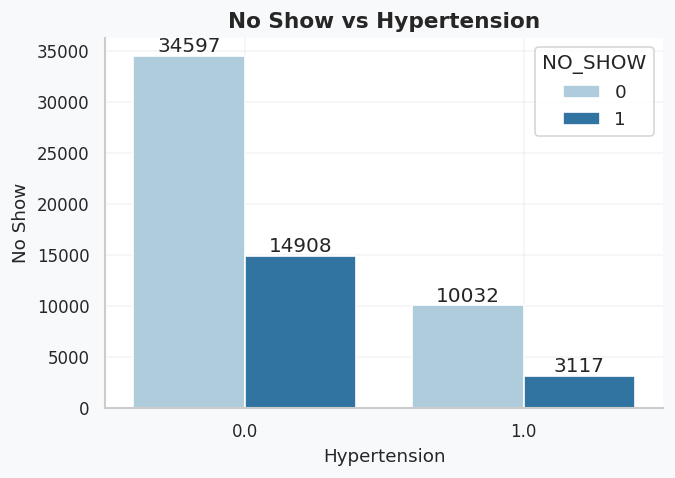

In [ ]:
# No Show vs Medical Condition
plt.figure(figsize=(6,4))
ax=sns.countplot(data=df, x='HYPERTENSION', hue='NO_SHOW')
for container in ax.containers:
  ax.bar_label(container)

plt.title("No Show vs Hypertension")
plt.xlabel("Hypertension")
plt.ylabel("No Show")
plt.grid(True, alpha=0.2)
plt.show()

In [ ]:
# High risk no show locations
location_risk = df.groupby('NEIGHBOURHOOD')['NO_SHOW'].mean()
location_risk = location_risk.sort_values(ascending=False)
print(location_risk.head(10))

NEIGHBOURHOOD
Ilhas Oceânicas De Trindade    1.000000
Jesus De Nazareth              0.389247
Horto                          0.386139
Gurigica                       0.382637
Itararé                        0.363191
Santos Dumont                  0.351759
Santa Clara                    0.339031
Santa Cecília                  0.336700
Ilha Do Príncipe               0.326812
Caratoíra                      0.323206
Name: NO_SHOW, dtype: float64


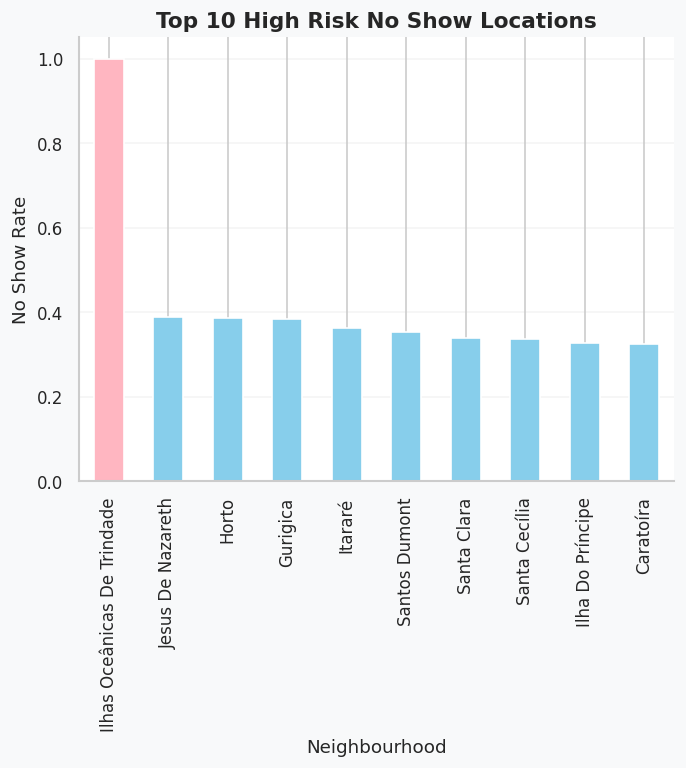

In [ ]:
colors = ['skyblue'] * len(top_locations)
colors[0] = 'lightpink'

top_locations.plot(kind='bar', color=colors)

plt.title("Top 10 High Risk No Show Locations")
plt.xlabel("Neighbourhood")
plt.ylabel("No Show Rate")
plt.xticks(rotation=90)
plt.grid(axis='y', alpha=0.2)
plt.show()

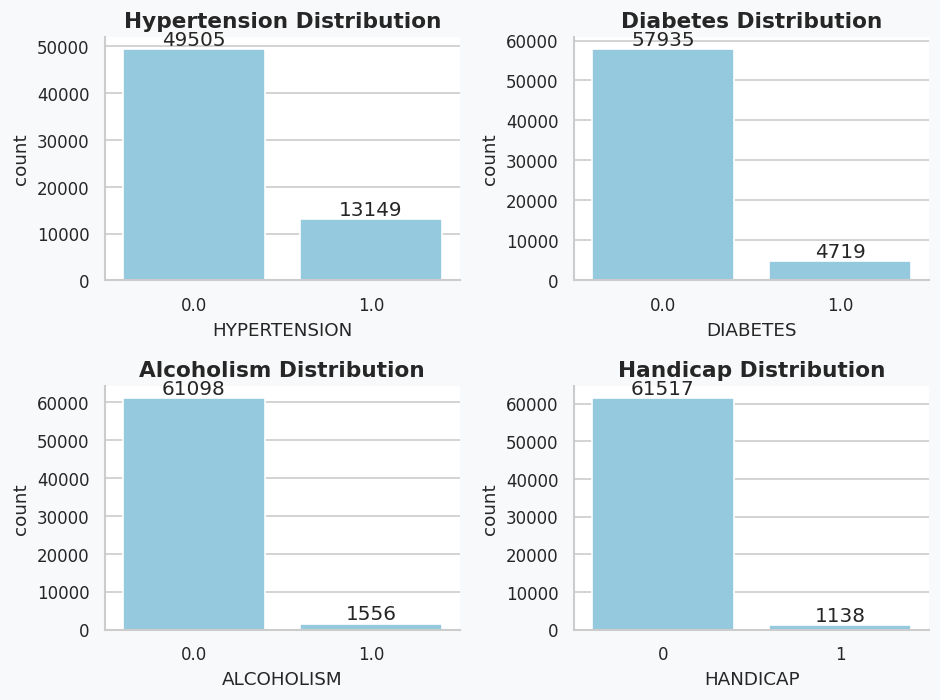

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(8,6))

# Hypertension
ax1 = sns.countplot(data=df, x='HYPERTENSION', ax=axes[0,0], color='skyblue')
axes[0,0].set_title("Hypertension Distribution")
for container in ax1.containers:
    ax1.bar_label(container)

# Diabetes
ax2 = sns.countplot(data=df, x='DIABETES', ax=axes[0,1], color='skyblue')
axes[0,1].set_title("Diabetes Distribution")
for container in ax2.containers:
    ax2.bar_label(container)

# Alcoholism
ax3 = sns.countplot(data=df, x='ALCOHOLISM', ax=axes[1,0], color='skyblue')
axes[1,0].set_title("Alcoholism Distribution")
for container in ax3.containers:
    ax3.bar_label(container)

# Handicap
ax4 = sns.countplot(data=df, x='HANDICAP', ax=axes[1,1], color='skyblue')
axes[1,1].set_title("Handicap Distribution")
for container in ax4.containers:
    ax4.bar_label(container)

plt.tight_layout()
plt.show()